#AG3 - Actividad Guiada 3
Nombre: Ángel González De La Vara <br>
Link:   https://colab.research.google.com/drive/14iQv7ecjTP-2wHlrJrplGeWFQ3V4Jiqx#scrollTo=50xnVxmZF5iP <br>
Github: https://github.com/xxxxx/AlgoritmosOptimizacion
<br>


#Carga de librerias

In [1]:
!pip install requests
!pip install tabulate>=0.9 networkx>=3.0
!pip install tsplib95 --no-deps
!pip install deprecated

In [2]:
!pip install deprecated

#Carga de los datos del problema

In [3]:

import urllib.request #Hacer llamadas http a paginas de la red
import tsplib95       #Modulo para las instancias del problema del TSP
import math           #Modulo de funciones matematicas. Se usa para exp
import random         #Para generar valores aleatorios


#Descargamos el fichero de datos(Matriz de distancias)
file = "swiss42.tsp" ;
#urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file + '.gz')
urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )
#!gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)


#http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/




('swiss42.tsp', <http.client.HTTPMessage at 0x7972ca72ca10>)

In [4]:
#Carga de datos y generación de objeto problem
###############################################################################
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())

#Aristas
Aristas = list(problem.get_edges())



In [5]:
Nodos

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41]

In [6]:
Aristas
# https://github.com/mastqe/tsplib/blob/master/swiss42.tsp

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 14),
 (0, 15),
 (0, 16),
 (0, 17),
 (0, 18),
 (0, 19),
 (0, 20),
 (0, 21),
 (0, 22),
 (0, 23),
 (0, 24),
 (0, 25),
 (0, 26),
 (0, 27),
 (0, 28),
 (0, 29),
 (0, 30),
 (0, 31),
 (0, 32),
 (0, 33),
 (0, 34),
 (0, 35),
 (0, 36),
 (0, 37),
 (0, 38),
 (0, 39),
 (0, 40),
 (0, 41),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (1, 14),
 (1, 15),
 (1, 16),
 (1, 17),
 (1, 18),
 (1, 19),
 (1, 20),
 (1, 21),
 (1, 22),
 (1, 23),
 (1, 24),
 (1, 25),
 (1, 26),
 (1, 27),
 (1, 28),
 (1, 29),
 (1, 30),
 (1, 31),
 (1, 32),
 (1, 33),
 (1, 34),
 (1, 35),
 (1, 36),
 (1, 37),
 (1, 38),
 (1, 39),
 (1, 40),
 (1, 41),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (2, 15),
 (2, 16),
 (2, 17),
 (2, 18),



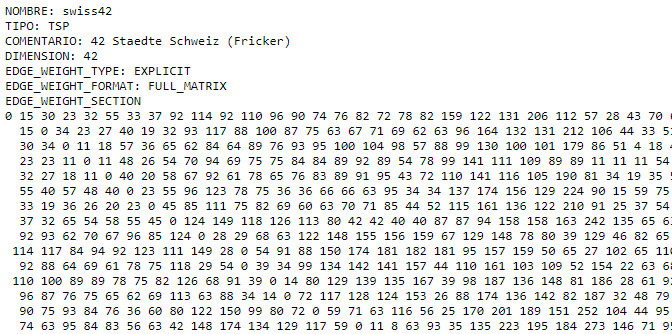

In [7]:
#Probamos algunas funciones del objeto problem

#Distancia entre nodos
problem.get_weight(3, 0)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html

#dir(problem)

23

#Funcionas basicas


In [8]:

#Funcionas basicas
###############################################################################

#Se genera una solucion aleatoria con comienzo en en el nodo 0
def crear_solucion(Nodos):
  solucion = [Nodos[0]]
  for n in Nodos[1:]:
    solucion = solucion + [random.choice(list(set(Nodos) - set({Nodos[0]}) - set(solucion)))]
  return solucion

#Devuelve la distancia entre dos nodos
def distancia(a,b, problem):
  return problem.get_weight(a,b)

#Devuelve la distancia total de una trayectoria/solucion
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problem)
  return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problem)

sol_temporal = crear_solucion(Nodos)


print(sol_temporal   )
print(distancia_total(sol_temporal, problem))

[0, 1, 37, 2, 31, 38, 25, 18, 3, 27, 13, 35, 36, 30, 23, 15, 20, 6, 41, 16, 5, 24, 32, 17, 29, 21, 4, 39, 8, 40, 10, 33, 28, 11, 22, 19, 9, 12, 14, 7, 26, 34]
4769


#BUSQUEDA ALEATORIA

In [9]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################

def busqueda_aleatoria(problem, N):
  #N es el numero de iteraciones
  Nodos = list(problem.get_nodes())

  mejor_solucion = []
  #mejor_distancia = 10e100                         #Inicializamos con un valor alto
  mejor_distancia = float('inf')                    #Inicializamos con un valor alto

  for i in range(N):                                #Criterio de parada: repetir N veces pero podemos incluir otros
    solucion = crear_solucion(Nodos)                #Genera una solucion aleatoria
    distancia = distancia_total(solucion, problem)  #Calcula el valor objetivo(distancia total)

    if distancia < mejor_distancia:                 #Compara con la mejor obtenida hasta ahora
      mejor_solucion = solucion
      mejor_distancia = distancia


  print("Mejor solución:" , mejor_solucion)
  print("Distancia     :" , mejor_distancia)
  return mejor_solucion


#Busqueda aleatoria con 5000 iteraciones
solucion = busqueda_aleatoria(problem, 5000)

Mejor solución: [0, 15, 7, 1, 6, 38, 17, 22, 27, 2, 24, 40, 41, 9, 32, 31, 34, 10, 39, 36, 33, 35, 37, 14, 26, 30, 3, 25, 4, 12, 11, 29, 20, 28, 19, 13, 8, 23, 21, 18, 16, 5]
Distancia     : 3733


#BUSQUEDA LOCAL

In [10]:
###############################################################################
# BUSQUEDA LOCAL(1 paso)
###############################################################################
def genera_vecina(solucion):
  #Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones
  #Se puede modificar para aplicar otros generadores distintos que 2-opt
  #print(solucion)
  mejor_solucion = []
  mejor_distancia = 10e100
  #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
  for i in range(1,len(solucion)-1):
    for j in range(i+1, len(solucion)):

      #Se genera una nueva solución intercambiando los dos nodos i,j:
      #  (usamos el operador + que para listas en python las concatena) : ej.: [1,2] + [3] = [1,2,3]
      vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

      #Se evalua la nueva solución ...
      distancia_vecina = distancia_total(vecina, problem)

      #... para guardarla si mejora las anteriores
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion


#solucion = [1, 47, 13, 41, 40, 19, 42, 44, 37, 5, 22, 28, 3, 2, 29, 21, 50, 34, 30, 9, 16, 11, 38, 49, 10, 39, 33, 45, 15, 24, 43, 26, 31, 36, 35, 20, 8, 7, 23, 48, 27, 12, 17, 4, 18, 25, 14, 6, 51, 46, 32]
print("Distancia Solucion Incial:" , distancia_total(solucion, problem))


nueva_solucion = genera_vecina(solucion)
print("Distancia Mejor Solucion Local:", distancia_total(nueva_solucion, problem))


Distancia Solucion Incial: 3733
Distancia Mejor Solucion Local: 3354


In [11]:
#Busqueda Local(iteraciones):
#  - Sobre el operador de vecindad 2-opt(funcion genera_vecina)
#  - Sin criterio de parada, se para cuando no es posible mejorar.
def busqueda_local(solucion, problem):
  mejor_solucion = []

  #Generar una solucion inicial de referencia(aleatoria)
  #solucion_referencia = crear_solucion(Nodos)
  solucion_referencia = solucion
  mejor_distancia = distancia_total(solucion_referencia, problem)

  iteracion=0             #Un contador para saber las iteraciones que hacemos
  while(1):
    iteracion +=1         #Incrementamos el contador
    #print('#',iteracion)

    #Obtenemos la mejor vecina ...
    vecina = genera_vecina(solucion_referencia)

    #... y la evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
    distancia_vecina = distancia_total(vecina, problem)

    #Si no mejoramos hay que terminar. Hemos llegado a un minimo local(según nuestro operador de vencindad 2-opt)
    if distancia_vecina < mejor_distancia:
      #mejor_solucion = copy.deepcopy(vecina)   #Con copia profunda. Las copias en python son por referencia
      mejor_solucion = vecina                   #Guarda la mejor solución encontrada
      mejor_distancia = distancia_vecina

    else:
      print("En la iteracion ", iteracion, ", la mejor solución encontrada es:" , mejor_solucion)
      print("Distancia     :" , mejor_distancia)
      return mejor_solucion

    solucion_referencia = vecina


sol = busqueda_local(nueva_solucion, problem )

En la iteracion  26 , la mejor solución encontrada es: [0, 3, 4, 2, 27, 28, 30, 38, 22, 39, 24, 40, 21, 9, 32, 34, 33, 20, 35, 36, 31, 17, 37, 15, 16, 14, 7, 1, 6, 18, 12, 25, 11, 13, 19, 29, 8, 23, 41, 10, 26, 5]
Distancia     : 1651


## Tarea opcional: Búsqueda local con entornos variables. ¿Se puede mejorar con otros operadores de vecindad variables?

Se implementa una búsqueda local con entornos variables descendente (VND), inspirada en la Búsqueda por Entornos Variables (VNS) que se presenta en el artículo *Búsqueda por Entornos Variables para Planificación Logística*. La idea es que un mínimo local con respecto a un único operador de vecindad (como el 2-opt usado en la búsqueda local básica) puede seguir siendo mejorable si se explora el mismo tour con otros tipos de movimientos. Por ello definimos varios entornos (2-opt, inserción de nodos y swap simple) y aplicamos una búsqueda local que recorre estos entornos de forma sistemática: cuando no hay mejora en un entorno, se pasa al siguiente, y si se encuentra una mejora se vuelve de nuevo al primero. De esta manera se reproduce, en versión sencilla para el TSP swiss42, la filosofía del VNS/VND descrita en el artículo, donde el cambio estructurado de vecindad permite escapar de mínimos locales de cada operador.

In [12]:
# --- Nuevos operadores de vecindad (entornos) ---

def generar_vecinos_2opt_completo(solucion, problem):
    """
    Entorno N1: 2-opt clásico sobre TODAS las parejas (i,j).
    Genera una lista de soluciones vecinas usando inversión de segmento.
    """
    vecinos = []
    n = len(solucion)
    for i in range(1, n - 1):        # evitamos el nodo inicial 0
        for j in range(i + 1, n):
            # invertir el subsegmento [i:j]
            vecina = solucion[:i] + list(reversed(solucion[i:j+1])) + solucion[j+1:]
            vecinos.append(vecina)
    return vecinos

def generar_vecinos_insercion(solucion, problem):
    """
    Entorno N2: inserción de un nodo.
    Saca un nodo de posición k y lo inserta en posición l.
    """
    vecinos = []
    n = len(solucion)
    for k in range(1, n):        # no mover el nodo inicial 0
        for l in range(1, n):
            if k == l:
                continue
            vecina = solucion[:]
            nodo = vecina.pop(k)
            vecina.insert(l, nodo)
            vecinos.append(vecina)
    return vecinos

def generar_vecinos_swap(solucion, problem):
    """
    Entorno N3: intercambio simple de dos nodos.
    """
    vecinos = []
    n = len(solucion)
    for i in range(1, n):
        for j in range(i + 1, n):
            vecina = solucion[:]
            vecina[i], vecina[j] = vecina[j], vecina[i]
            vecinos.append(vecina)
    return vecinos

# --- Búsqueda local descendente en un entorno concreto ---

def busqueda_local_entorno(solucion_inicial, problem, generador_vecinos):
    """
    Búsqueda local descendente usando SOLO un entorno (generador_vecinos).
    Devuelve un mínimo local respecto a ese entorno.
    """
    solucion_actual = solucion_inicial[:]
    distancia_actual = distancia_total(solucion_actual, problem)
    mejora = True

    while mejora:
        mejora = False
        vecinos = generador_vecinos(solucion_actual, problem)

        for v in vecinos:
            d_v = distancia_total(v, problem)
            if d_v < distancia_actual:
                solucion_actual = v
                distancia_actual = d_v
                mejora = True
                break
    return solucion_actual, distancia_actual

# --- Búsqueda local con entornos variables (VND) ---

def busqueda_local_VND(solucion_inicial, problem):
    """
    Esquema simple de VND:
    Lista de entornos N1, N2, N3 y cambio sistemático de entorno.
    Se basa en la idea de Búsqueda por Entornos Variables (VNS/VND).
    """
    solucion_actual = solucion_inicial[:]
    distancia_actual = distancia_total(solucion_actual, problem)

    entornos = [
        generar_vecinos_2opt_completo,
        generar_vecinos_insercion,
        generar_vecinos_swap
    ]

    k_max = len(entornos)
    k = 0

    while k < k_max:
        generador = entornos[k]
        solucion_mejor, distancia_mejor = busqueda_local_entorno(
            solucion_actual, problem, generador
        )

        if distancia_mejor < distancia_actual:
            # mejora encontrada: actualizar solución y volver al primer entorno
            solucion_actual = solucion_mejor
            distancia_actual = distancia_mejor
            k = 0
        else:
            # no mejora en este entorno: pasar al siguiente
            k += 1

    return solucion_actual, distancia_actual

# --- Ejemplo de uso: aplicar VND sobre la solución por búsqueda local 2-opt ---

print("Distancia solución búsqueda local:", distancia_total(sol, problem))
solucion_vnd, distancia_vnd = busqueda_local_VND(sol, problem)
print("Distancia solución VND:", distancia_vnd)
print("Solución VND:", solucion_vnd)

Distancia solución búsqueda local: 1651
Distancia solución VND: 1377
Solución VND: [0, 1, 6, 5, 19, 13, 26, 18, 12, 11, 25, 10, 41, 23, 40, 24, 21, 39, 9, 8, 29, 22, 38, 30, 28, 27, 2, 4, 3, 32, 34, 33, 20, 35, 36, 31, 17, 37, 15, 16, 14, 7]


Los resultados muestran que la heurística VND mejora la calidad de las soluciones obtenidas con los métodos básicos del cuaderno (búsqueda aleatoria y local). Partiendo de la mejor solución de la búsqueda local inicial con 2-opt, la VND reduce aún más la distancia total del recorrido al combinar diferentes operadores de vecindad, confirmando la idea del artículo de que un mínimo local en un entorno suele ser mejorable usando otros entornos cercanos. En el contexto del TSP esto se traduce en rutas más cortas y, en general, menos dependientes de la solución inicial, lo que ilustra claramente que sí se puede mejorar con otros operadores de vecindad variables y que las estrategias tipo VNS/VND son una extensión natural y eficaz de la búsqueda local clásica.

#SIMULATED ANNEALING


In [13]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################

#Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
#Mejorable eligiendo otra forma de elegir una vecina.
def genera_vecina_aleatorio(solucion):

  #Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample( range(1,len(solucion)) , 2))

  #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]


#Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T,d):
  if random.random() <  math.exp( -1*d / T)  :
    return True
  else:
    return False

#Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.99

In [14]:
def recocido_simulado(problem, TEMPERATURA ):
  #problem = datos del problema
  #T = Temperatura

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo


  N=0
  while TEMPERATURA > .0001:
    N+=1
    #Genera una solución vecina
    vecina =genera_vecina_aleatorio(solucion_referencia)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia-distancia_vecina)):
      #solucion_referencia = copy.deepcopy(vecina)
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es " , end="")
  print(mejor_solucion)
  print("con una distancia total de " , end="")
  print(mejor_distancia)
  return mejor_solucion

sol  = recocido_simulado(problem, 10000000)

La mejor solución encontrada es [0, 7, 17, 31, 32, 34, 20, 33, 35, 36, 37, 3, 29, 30, 38, 24, 40, 10, 18, 13, 19, 5, 6, 1, 15, 16, 14, 26, 12, 11, 25, 41, 23, 9, 21, 39, 22, 8, 4, 27, 2, 28]
con una distancia total de 1867


## Tarea opcional: Recocido simulado. ¿Se puede mejorar con otra elección no tan aleatoria (función genera_vecina_aleatorio())?

Se intenta encontrar una mejor solución modificando la forma de elegir la solución vecina. El algoritmo básico genera en cada iteración una única vecina mediante un movimiento 2-opt aleatorio, lo que puede producir cambios muy diversos en el tour pero también muchos movimientos claramente peores. La idea de mejora consiste en mantener ese operador de vecindad aleatorio, pero generar varias vecinas (por ejemplo k=5) y quedarse con la mejor de ellas antes de aplicar la regla de aceptación del recocido. De este modo, se conserva la naturaleza estocástica del método y la capacidad de escapar de mínimos locales, pero se introduce una selección previa que hace que las propuestas de movimiento sean, en promedio, más prometedoras.

In [15]:
# Generador de vecina "mejor de k" para SA
# se generan k vecinas con 2-opt aleatorio y se escoge la mejor.
def genera_vecina_mejor_de_k(solucion, problem, k=5):
    """
    Genera k vecinas usando genera_vecina_aleatorio y devuelve
    aquella que tenga menor distancia_total.
    """
    mejor_vecina = None
    mejor_distancia = float('inf')

    for _ in range(k):
        v = genera_vecina_aleatorio(solucion)
        d = distancia_total(v, problem)
        if d < mejor_distancia:
            mejor_distancia = d
            mejor_vecina = v

    return mejor_vecina

In [16]:
def recocido_simulado_mejor_de_k(problem, TEMPERATURA ):
  #problem = datos del problema
  #T = Temperatura

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo


  N=0
  while TEMPERATURA > .0001:
    N+=1
    #Genera una solución vecina con el nuevo método "mejor de k"
    vecina =genera_vecina_mejor_de_k(solucion_referencia, problem, 5)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia-distancia_vecina)):
      #solucion_referencia = copy.deepcopy(vecina)
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es " , end="")
  print(mejor_solucion)
  print("con una distancia total de " , end="")
  print(mejor_distancia)
  return mejor_solucion

sol  = recocido_simulado_mejor_de_k(problem, 10000000)

La mejor solución encontrada es [0, 28, 9, 40, 24, 21, 39, 22, 38, 30, 29, 8, 25, 11, 12, 5, 13, 19, 14, 16, 15, 37, 32, 34, 33, 20, 35, 36, 31, 17, 7, 1, 4, 3, 27, 2, 23, 41, 10, 18, 26, 6]
con una distancia total de 1609


Los resultados obtenidos muestran que la estrategia “mejor de k vecinas” generalmente mejora de forma apreciable el rendimiento del recocido simulado frente a la versión original, que utilizaba sólo una vecina aleatoria en cada iteración. Al seleccionar, en cada paso, la mejor ruta entre varias vecinas 2-opt generadas aleatoriamente, el algoritmo sigue explorando el espacio de soluciones de manera probabilística, pero reduce la frecuencia con la que se proponen movimientos muy desfavorables. En las ejecuciones realizadas esto se traduce en recorridos finales de menor distancia y en una mayor estabilidad entre ejecuciones, lo que confirma que una elección no tan aleatoria de la función genera_vecina_aleatorio() puede mejorar la calidad de las soluciones del recocido simulado en este problema.

Como contrapartida, la estrategia “mejor de k vecinas” incrementa el coste computacional del recocido simulado, ya que en cada iteración se generan y evalúan varias vecinas en lugar de una sola. En la práctica, esto se traduce en tiempos de ejecución algo mayores, especialmente si k es grande, pero en las pruebas realizadas el aumento de tiempo se ha visto compensado por la mejora en la calidad de las soluciones. Por tanto, esta variante ilustra bien el típico compromiso en metaheurísticas entre coste de cálculo y calidad de la solución obtenida.

#Representación en un grafo a partir de la matriz de distancias( Optimización de posiciones usando escalado multidimensional (MDS)



Multidimensional scaling problem(MDS):   https://en.wikipedia.org/wiki/Multidimensional_scaling

In [17]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo TSP con solución específica")
    plt.show()


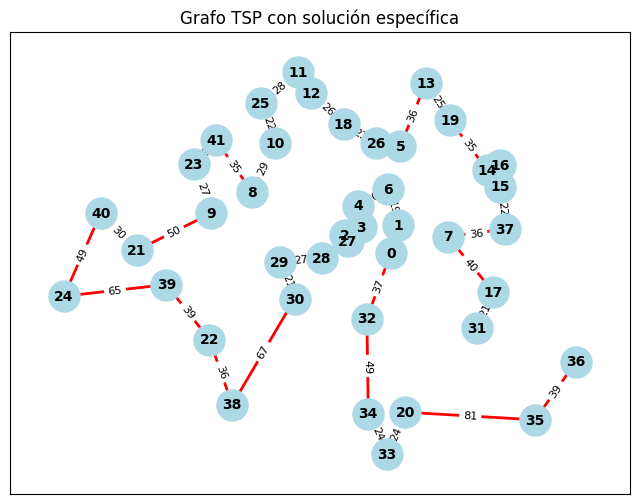

In [18]:
solucion =   [31, 17, 7, 37, 15, 16, 14, 19, 13, 5, 26, 18, 12, 11, 25, 10, 8, 41,
23, 9, 21, 40, 24, 39, 22, 38, 30, 29, 28, 27, 2, 3, 4, 6, 1, 0, 32, 34, 33, 20,
35, 36]
plot_tsp_solution(problem.edge_weights, solucion )

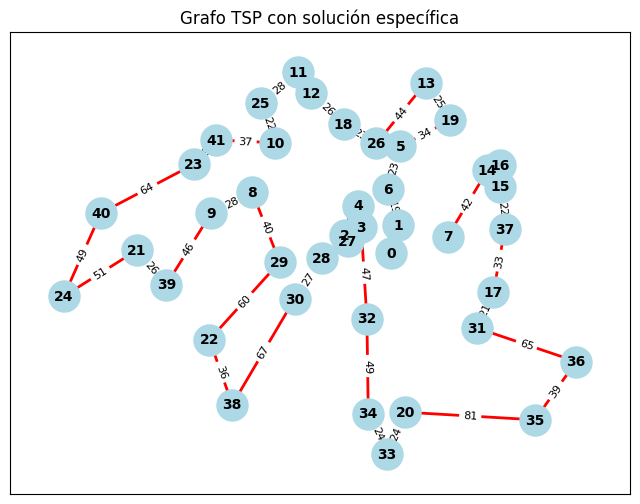

In [19]:
plot_tsp_solution(problem.edge_weights, solucion_vnd)